In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_validate, KFold


In [3]:
# 2. Data Loading and Preprocessing
df = pd.read_csv("extracted_columns.csv")

X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7', 
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']


In [7]:
df.head()

,SDD_1,SDD_2,SDD_3,PSS-1,PSS-2,PSS-3,PSS-4,PSS-5,PSS-6,PSS-7,PSS-8,PSS-9,PSS-10,PSS-11,PSS-12,PSS-13,PSS-14,PSS_total
0,Male,22,4th Year,1,2,1,1,1,0,1,3,1,2,1,2,2,1,19
1,Female,21,4th Year,4,3,3,2,2,1,2,3,2,2,4,3,2,3,36
2,Male,21,4th Year,4,3,2,1,2,1,3,2,3,2,3,4,1,4,35
3,Female,20,4th Year,2,4,2,2,0,3,2,3,1,3,0,4,1,1,28
4,Female,20,4th Year,2,4,2,2,4,2,4,2,3,2,3,1,3,3,37


In [8]:
df.shape

(1105, 18)

In [9]:
df.isnull().sum()

SDD_1        0
SDD_2        0
SDD_3        0
PSS-1        0
PSS-2        0
PSS-3        0
PSS-4        0
PSS-5        0
PSS-6        0
PSS-7        0
PSS-8        0
PSS-9        0
PSS-10       0
PSS-11       0
PSS-12       0
PSS-13       0
PSS-14       0
PSS_total    0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SDD_1      1105 non-null   object
 1   SDD_2      1105 non-null   int64 
 2   SDD_3      1105 non-null   object
 3   PSS-1      1105 non-null   int64 
 4   PSS-2      1105 non-null   int64 
 5   PSS-3      1105 non-null   int64 
 6   PSS-4      1105 non-null   int64 
 7   PSS-5      1105 non-null   int64 
 8   PSS-6      1105 non-null   int64 
 9   PSS-7      1105 non-null   int64 
 10  PSS-8      1105 non-null   int64 
 11  PSS-9      1105 non-null   int64 
 12  PSS-10     1105 non-null   int64 
 13  PSS-11     1105 non-null   int64 
 14  PSS-12     1105 non-null   int64 
 15  PSS-13     1105 non-null   int64 
 16  PSS-14     1105 non-null   int64 
 17  PSS_total  1105 non-null   int64 
dtypes: int64(16), object(2)
memory usage: 155.5+ KB


In [4]:
# Split into training and test (held-out) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# Define Random Forest pipeline
rfr_pipe = make_pipeline(
    StandardScaler(),  # Scale numerical features; optional but recommended
    RandomForestRegressor(random_state=42)
)

In [13]:
# Apply 5-fold cross-validation on training set for model assessment
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']

cv_results = cross_validate(rfr_pipe, X_train, y_train, cv=kf, scoring=scoring)

print('Random Forest Average RMSE (Train CV):', -np.mean(cv_results['test_neg_root_mean_squared_error']))
print('Random Forest Average MAE (Train CV):', -np.mean(cv_results['test_neg_mean_absolute_error']))
print('Random Forest Average R^2 (Train CV):', np.mean(cv_results['test_r2']))


Random Forest Average RMSE (Train CV): 2.052724235050191
Random Forest Average MAE (Train CV): 1.5426728941961991
Random Forest Average R^2 (Train CV): 0.9192917765162422


In [14]:
# Train final model on full training set
rfr_pipe.fit(X_train, y_train)


,steps,"[('standardscaler', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [15]:
# Predict on test set (held-out data)
y_test_pred = rfr_pipe.predict(X_test)

In [16]:
# Evaluate performance on test set
rmse_test = np.sqrt(np.mean((y_test - y_test_pred)**2))
mae_test = np.mean(np.abs(y_test - y_test_pred))
r2_test = rfr_pipe.score(X_test, y_test)

print(f"Random Forest Test RMSE: {rmse_test:.4f}")
print(f"Random Forest Test MAE: {mae_test:.4f}")
print(f"Random Forest Test R^2: {r2_test:.4f}")


Random Forest Test RMSE: 1.8911
Random Forest Test MAE: 1.4853
Random Forest Test R^2: 0.9491


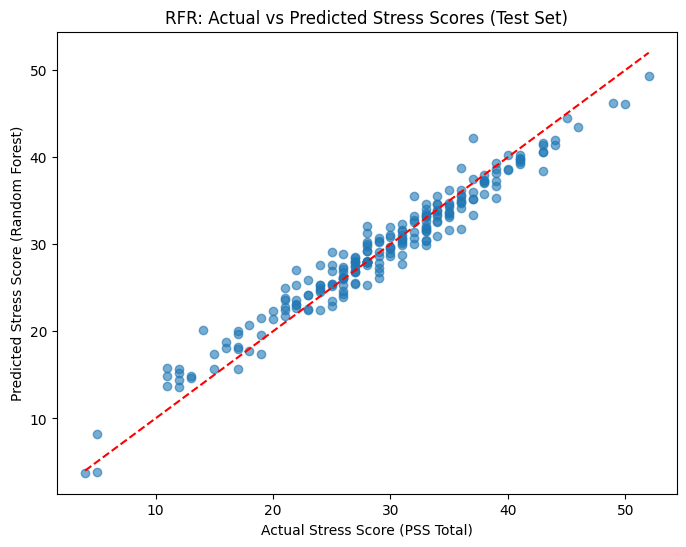

In [17]:
# Plot actual vs predicted on test set
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Stress Score (PSS Total)')
plt.ylabel('Predicted Stress Score (Random Forest)')
plt.title('RFR: Actual vs Predicted Stress Scores (Test Set)')
plt.show()


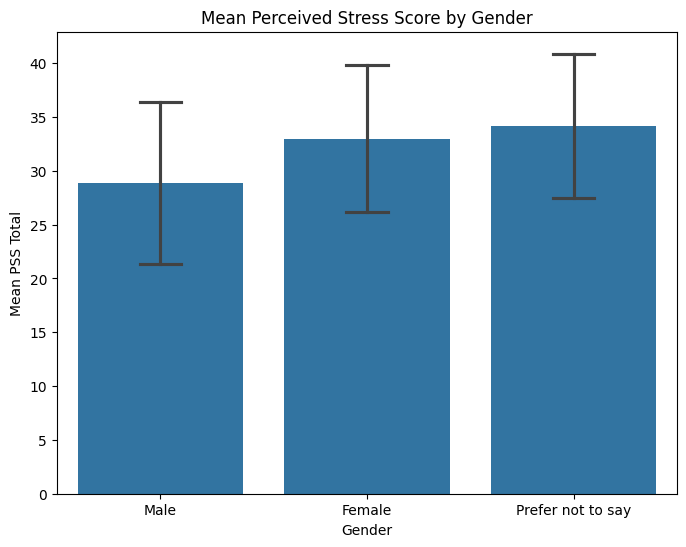

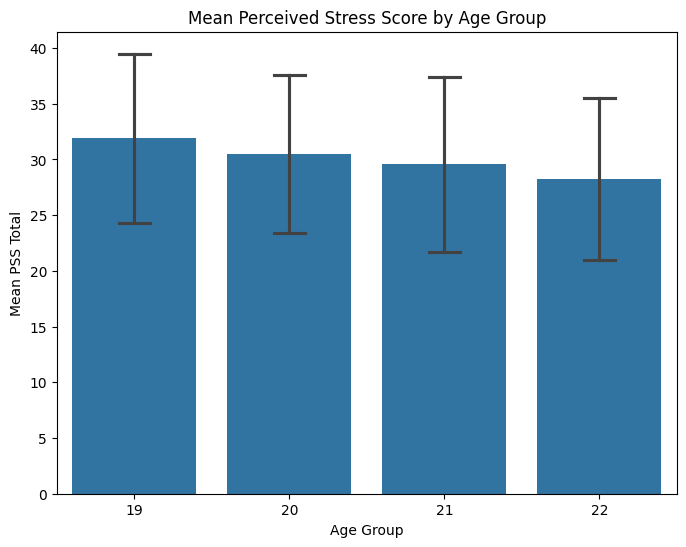

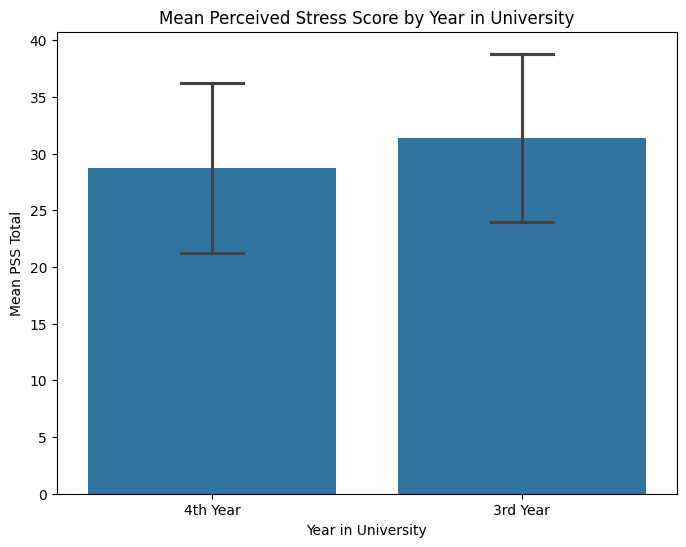

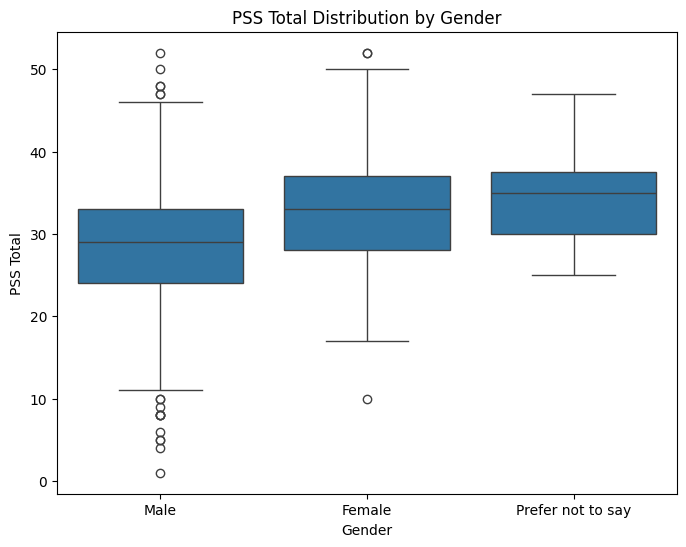

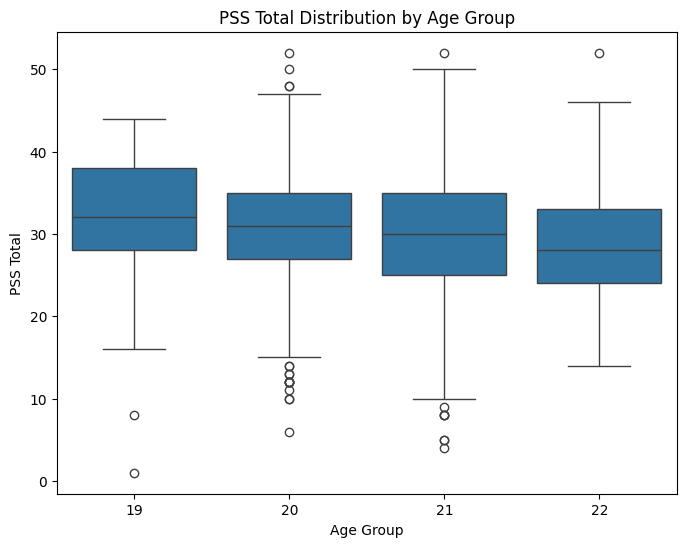

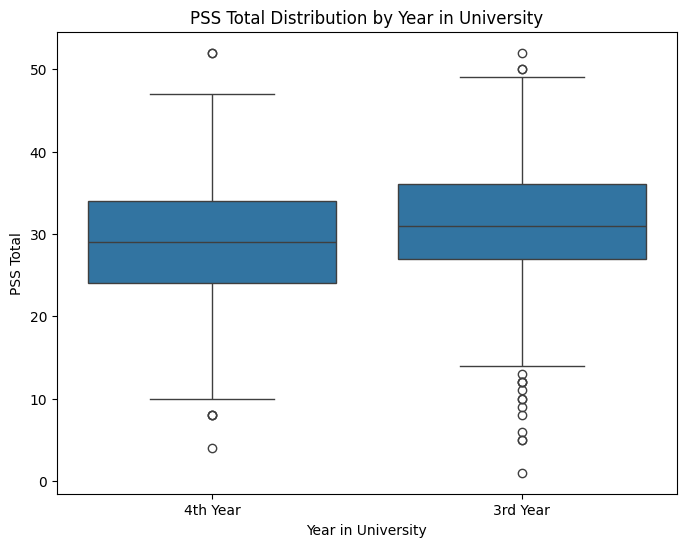

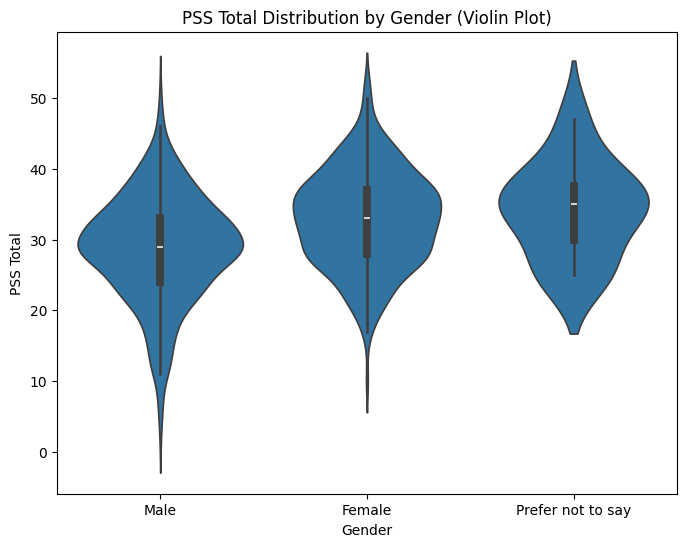

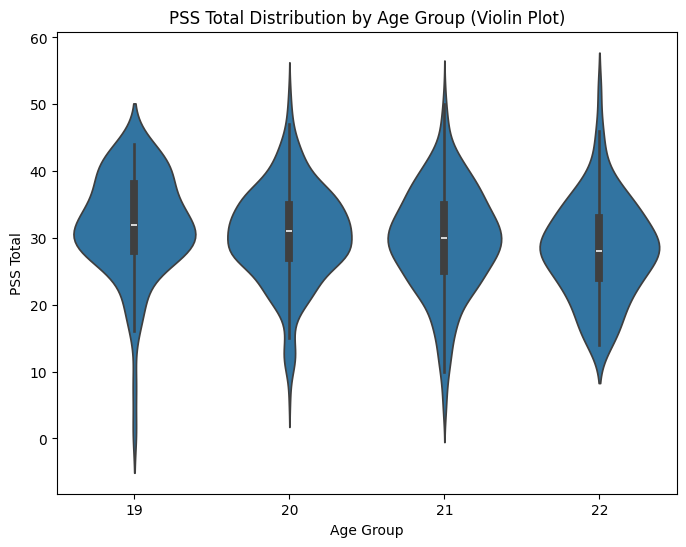

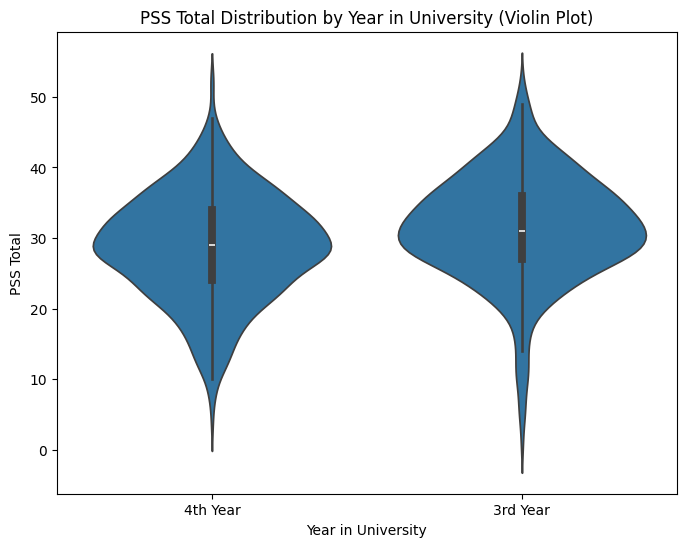

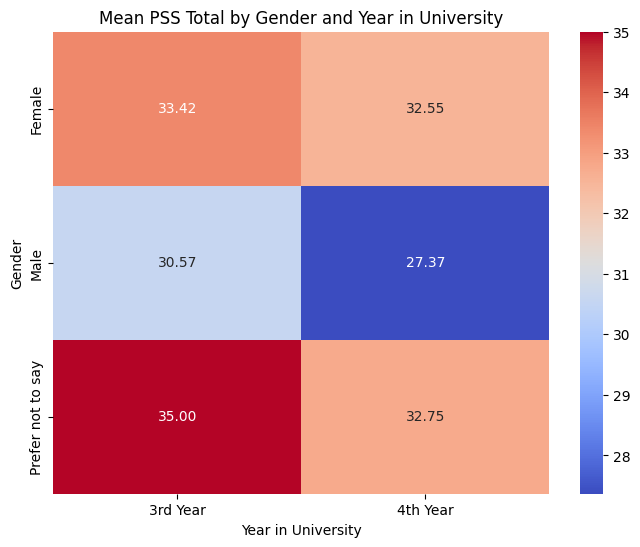

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define demographic columns
gender_col = 'SDD_1'
age_col = 'SDD_2'
year_col = 'SDD_3'

# 1. Bar plot: Mean PSS_total by demographic groups with error bars (std dev)
def plot_mean_stress_by_group(col, title):
    grouped = df.groupby(col)['PSS_total'].agg(['mean', 'std']).reset_index()
    plt.figure(figsize=(8,6))
    sns.barplot(x=col, y='PSS_total', data=df, estimator=np.mean, errorbar='sd', capsize=0.2)
    plt.title(f'Mean Perceived Stress Score by {title}')
    plt.ylabel('Mean PSS Total')
    plt.xlabel(title)
    plt.show()

plot_mean_stress_by_group(gender_col, 'Gender')
plot_mean_stress_by_group(age_col, 'Age Group')
plot_mean_stress_by_group(year_col, 'Year in University')

# 2. Box plot: Show distribution of PSS_total by demographic groups
def plot_boxplot(col, title):
    plt.figure(figsize=(8,6))
    sns.boxplot(x=col, y='PSS_total', data=df)
    plt.title(f'PSS Total Distribution by {title}')
    plt.ylabel('PSS Total')
    plt.xlabel(title)
    plt.show()

plot_boxplot(gender_col, 'Gender')
plot_boxplot(age_col, 'Age Group')
plot_boxplot(year_col, 'Year in University')

# 3. Violin plot: Display full distribution shape for deeper insight
def plot_violin(col, title):
    plt.figure(figsize=(8,6))
    sns.violinplot(x=col, y='PSS_total', data=df)
    plt.title(f'PSS Total Distribution by {title} (Violin Plot)')
    plt.ylabel('PSS Total')
    plt.xlabel(title)
    plt.show()

plot_violin(gender_col, 'Gender')
plot_violin(age_col, 'Age Group')
plot_violin(year_col, 'Year in University')

# 4. Heatmap: Show mean PSS_total by combinations of two demographics (example gender vs year)
pivot = df.pivot_table(values='PSS_total', index=gender_col, columns=year_col, aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mean PSS Total by Gender and Year in University')
plt.ylabel('Gender')
plt.xlabel('Year in University')
plt.show()
